# T31 — Geochemistry-corrected paleo-elevation: from samples to comparison

**Cluster G: paleo-geography and paleo-topography.**

Adapted from the EarthByte *Paleotopography Data Assimilation (https://github.com/EarthByte/paleotopo-data-assimilation)* repository
(Zhou, J., Müller, R.D., Farahbakhsh, E., in review. *From qualitative to data-assimilated paleotopography: an open framework for amplitude-corrected Phanerozoic elevation models.* Earth-Science Reviews.). The notebook splits into two parts:

1. **Sample distribution.** Three pyGMT figures characterising the
   geochemistry compilation that drives the assimilation: a global map
   of present-day sample positions, an age-density histogram, and a
   declustered sample count by tectonic province and era.
2. **Scotese-Wright vs corrected comparison.** For each of three age
   pairs (500-400 Ma, 300-200 Ma, 100-50 Ma) a pyGMT Winkel-Tripel 2×3
   figure shows the original Scotese & Wright (2018) (https://www.earthbyte.org/paleodem-resource-scotese-and-wright-2018/) PaleoDEM, the
   geochemistry-corrected map, and their difference Δz = corrected -
   original.

## Source
- Paleotopography Data Assimilation public repo (Scotese branch):
  `./external/paleotopo-data-assimilation/public_repo_scotese (https://github.com/EarthByte/paleotopo-data-assimilation)/`
- Paper: Zhou, J., Müller, R.D., Farahbakhsh, E., *From qualitative
  to data-assimilated paleotopography: an open framework for
  amplitude-corrected Phanerozoic elevation models*, in review,
  Earth-Science Reviews.

## Bundled data (in `data/paleotopo_scotese/`)
- `geochem_samples_slim.csv` — Lat / Lon / Age_Ma / Tecto_Prov for
  69,201 Phanerozoic samples (slim copy of the master 117-column CSV).
- `corrected_SW/{500,400,300,200,100,50}Ma_corrected_SW.nc` — per-age
  corrected NetCDFs with variables `M_orig`, `M_corrected`, `delta`,
  `continent_mask`, plus `lat` / `lon` axes.

## Learning objectives
1. Build pyGMT one-figure-per-panel layouts for both global maps and
   non-geographic plots (histograms, stacked bars).
2. Build a multi-panel pyGMT Winkel-Tripel comparison figure with
   shared colorbars across columns and a separate diverging Δz colorbar.
3. Read corrected paleo-DEM NetCDFs and wrap them as pixel-registered
   geographic xarray DataArrays for pyGMT consumption.

## Prerequisites
- pandas, numpy, xarray, netCDF4
- pyGMT 0.10+, GMT 6.x
- Runtime: ~1-2 min total on a laptop.


## Configuration

In [1]:
# === USER CONFIGURATION =====================================================
from pathlib import Path
import os as _os
if Path("../data").exists() and not Path("data").exists():
    _os.chdir("..")

import sys
import numpy as np
import pandas as pd
import xarray as xr
import netCDF4 as nc
import pygmt
from IPython.display import display, HTML

# ------------------------- Sample distribution inputs ---------------
CSV_PATH        = Path("data/paleotopo_scotese/geochem_samples_slim.csv")

# ------------------------- Comparison-figure inputs ------------------------
CORRECTED_DIR   = Path("data/paleotopo_scotese/corrected_SW")
AGE_PAIRS       = [(500, 400, "500-400Ma"),
                   (300, 200, "300-200Ma"),
                   (100,  50, "100-50Ma")]

# Comparison-figure visual conventions (from public_repo_scotese/make_comparison_figures.py)
ELEV_CPT        = "earth"
DELTA_CPT       = "polar"
ELEV_RANGE      = (-4000.0, 4000.0, 250.0)   # m
DELTA_RANGE     = (-2000.0, 2000.0, 100.0)   # m
PROJ_BASE       = "R0"        # Winkel-Tripel centred at lon=0
REGION          = "g"         # global
WIDTH_CM        = 10.0        # per-panel width in cm

# Save high-res copies of every figure to disk (alongside notebook outputs)
SAVE_FIG_DIR    = Path("paleotopo_scotese_figs")
SAVE_FIG_DIR.mkdir(parents=True, exist_ok=True)
# ============================================================================


## 1. Sample distribution

Three separate pyGMT figures (one per panel, per house style):
**(a)** global sample-position map coloured by age,
**(b)** age histogram on log y with K-Pg / P-Tr era boundaries marked,
**(c)** sample count by tectonic province × era (stacked horizontal bars).


Loading data/paleotopo_scotese/geochem_samples_slim.csv ...
  69,201 samples in 0-540 Ma


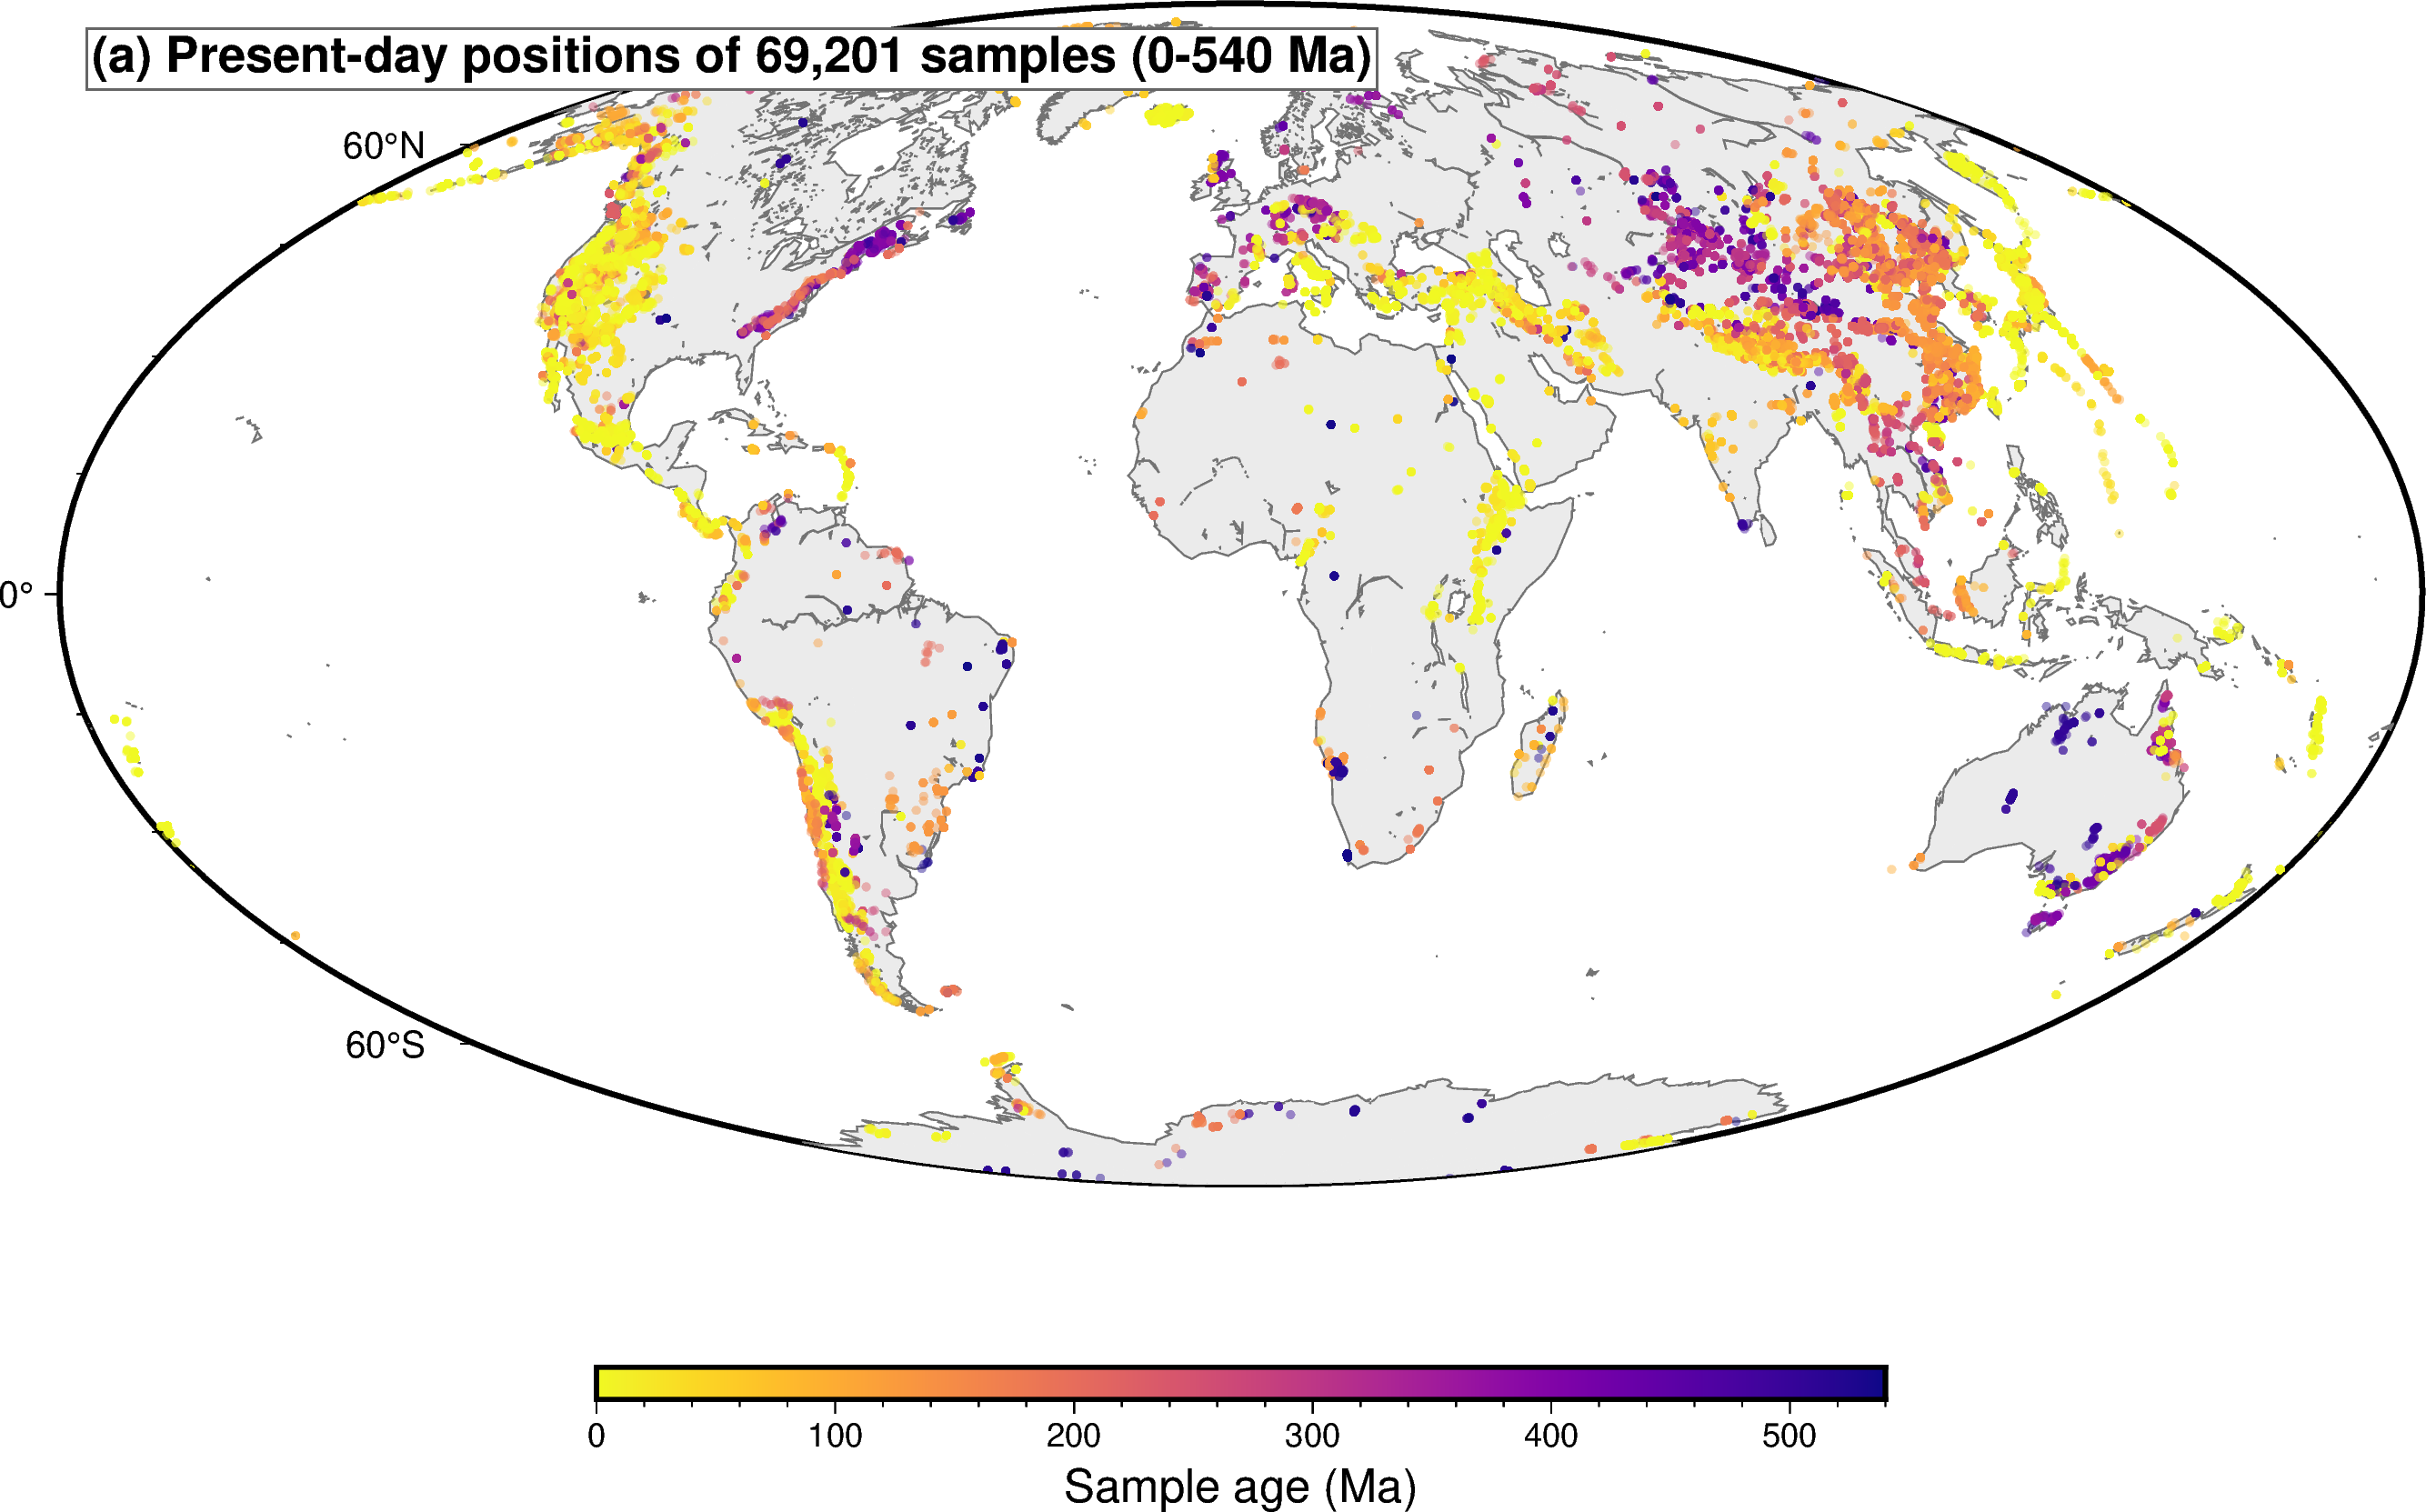

  saved: paleotopo_scotese_figs/T42_sample_map.png


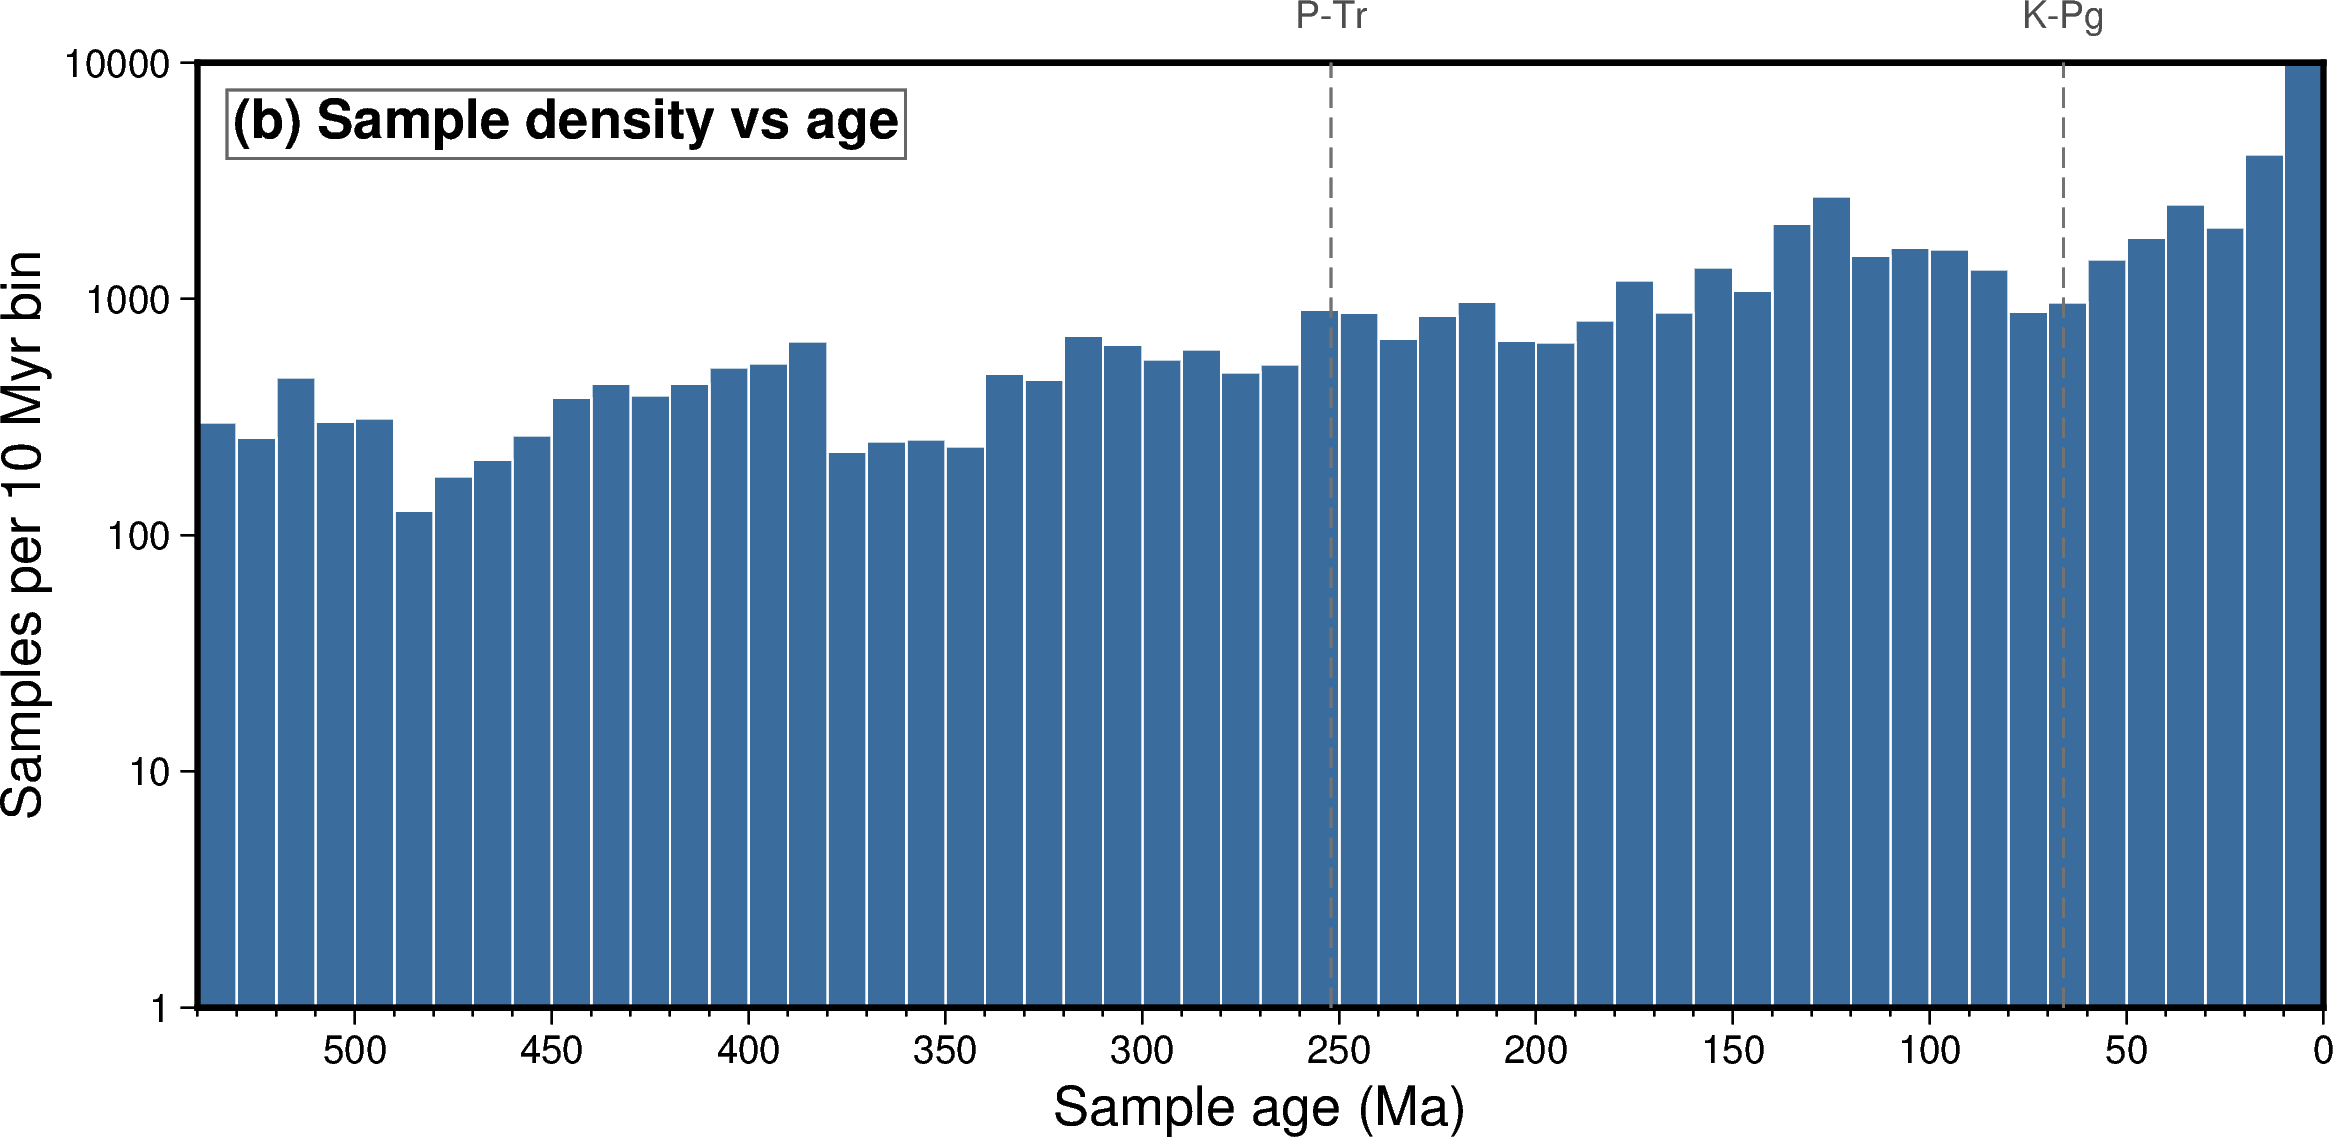

  saved: paleotopo_scotese_figs/T42_age_histogram.png


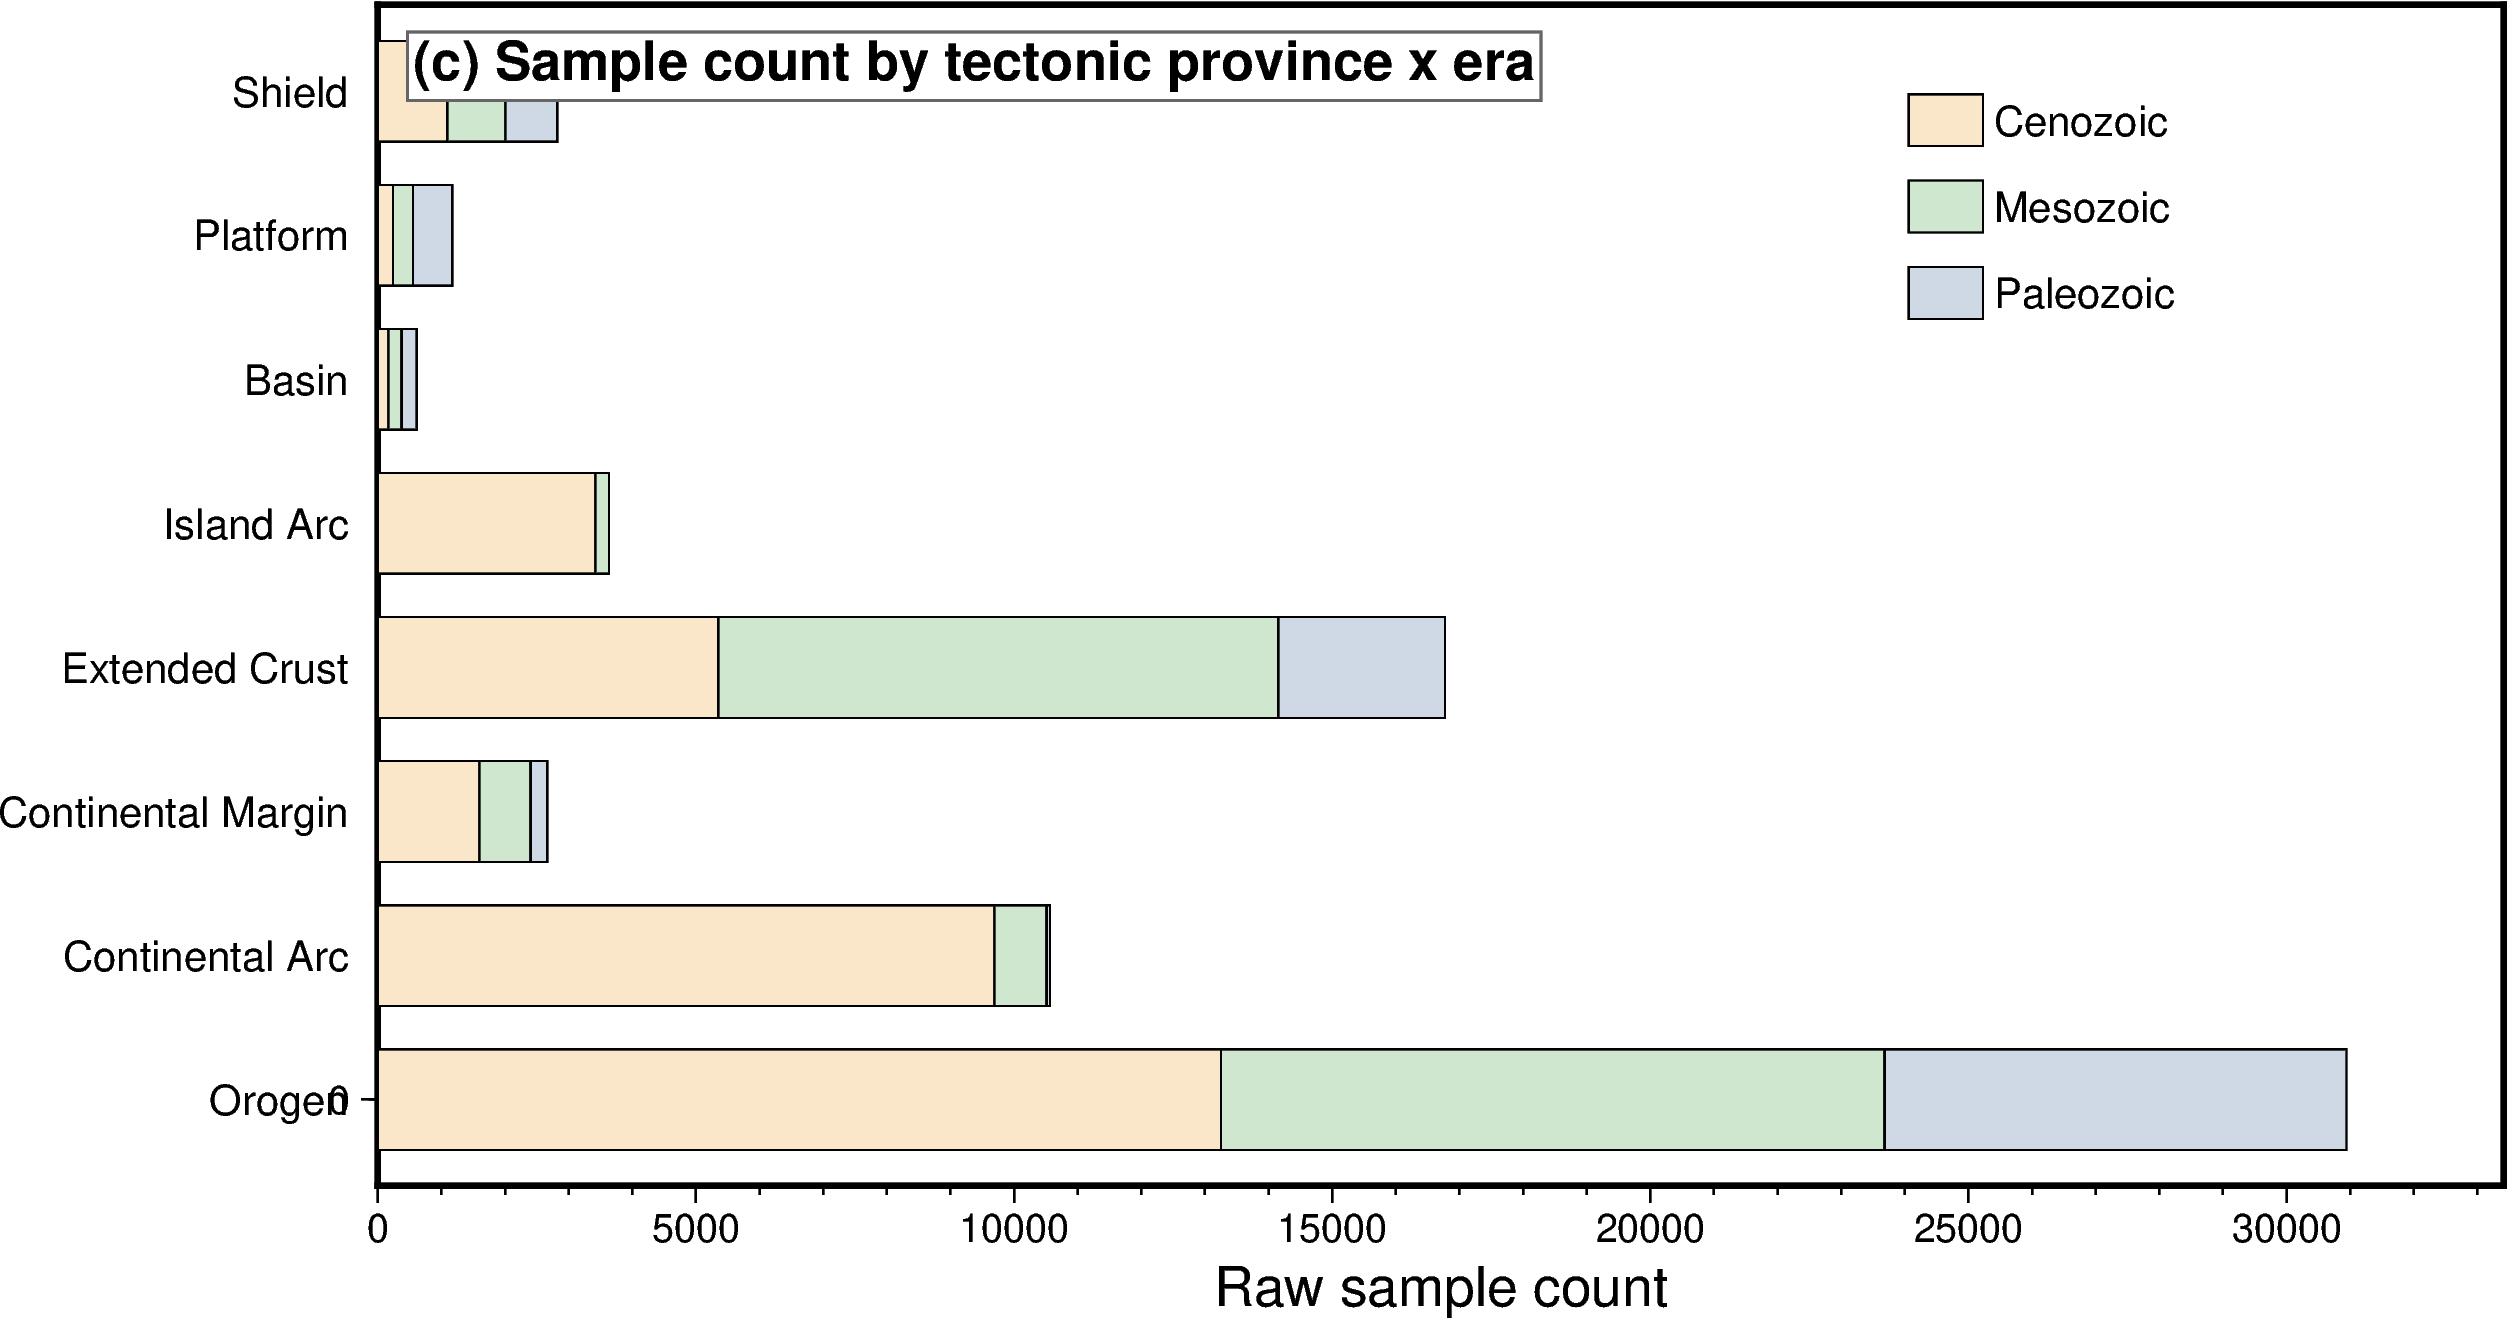

  saved: paleotopo_scotese_figs/T42_province_era_bars.png


In [2]:
# Sample distribution (all pyGMT, one Figure per panel).
# Adapted from public_repo_scotese/scripts/make_sample_distribution_figure.py
def era_of(t):
    if t < 66:  return "Cenozoic"
    if t < 252: return "Mesozoic"
    if t < 540: return "Paleozoic"
    return "older"

print(f"Loading {CSV_PATH} ...")
df = pd.read_csv(CSV_PATH, low_memory=False)
df = df.dropna(subset=["Lat", "Lon", "Age_Ma"]).copy()
df = df[(df["Age_Ma"] >= 0) & (df["Age_Ma"] <= 540)].reset_index(drop=True)
print(f"  {len(df):,} samples in 0-540 Ma")

# === (a) global sample map, coloured by age ==================================
fig_a = pygmt.Figure()
fig_a.basemap(region="d", projection="W0/22c", frame=["af"])
fig_a.coast(land="gray92", shorelines="0.4p,gray45")
pygmt.makecpt(cmap="plasma", series=[0, 540, 10],
              continuous=True, reverse=True)
fig_a.plot(x=df["Lon"].to_numpy(),
           y=df["Lat"].to_numpy(),
           style="c0.08c",
           fill=df["Age_Ma"].to_numpy(),
           cmap=True,
           transparency=55)
fig_a.colorbar(frame='af+lSample age (Ma)',
               position="JBC+w12c/0.3c+h+o0/1.7c")
fig_a.text(text=f"(a) Present-day positions of {len(df):,} samples (0-540 Ma)",
           position="TL", offset="0.3c/-0.3c", justify="TL",
           font="13p,Helvetica-Bold,black",
           fill="white", pen="0.6p,gray40")
out_a = SAVE_FIG_DIR / "T42_sample_map.png"
fig_a.savefig(out_a, dpi=200)
fig_a.show(width=1200)
display(HTML('<div style="height:1.0cm"></div>'))
print(f"  saved: {out_a}")

# === (b) age histogram (log y, x inverted: old on left) ======================
fig_b = pygmt.Figure()
# pyGMT histogram won't accept x_max < x_min; invert the x-axis instead
# by giving the projection a NEGATIVE width (X-18c = right-to-left x).
fig_b.histogram(data=df["Age_Ma"].to_numpy(),
                region=[0, 540, 1, 1e4],
                projection="X-18c/8cl",
                frame=['xaf+lSample age (Ma)',
                       'ya1f+lSamples per 10 Myr bin',
                       "WSrt"],
                series=10,
                pen="0.4p,white",
                fill="#3a6c9e",
                histtype=0)
# Era boundary verticals + labels (K-Pg = 66 Ma, P-Tr = 252 Ma).
for boundary, name in [(66, "K-Pg"), (252, "P-Tr")]:
    fig_b.plot(x=[boundary, boundary], y=[1, 1e4],
               pen="0.6p,gray45,dashed")
    fig_b.text(x=boundary, y=1.4e4, text=name,
               font="9p,Helvetica,gray30",
               justify="CB", no_clip=True)
fig_b.text(text="(b) Sample density vs age",
           position="TL", offset="0.3c/-0.3c", justify="TL",
           font="13p,Helvetica-Bold,black",
           fill="white", pen="0.6p,gray40")
out_b = SAVE_FIG_DIR / "T42_age_histogram.png"
fig_b.savefig(out_b, dpi=200)
fig_b.show(width=1100)
display(HTML('<div style="height:1.0cm"></div>'))
print(f"  saved: {out_b}")

# === (c) province x era stacked horizontal bars ==============================
df["era"]  = df["Age_Ma"].apply(era_of)
df["prov"] = df["Tecto_Prov"].fillna("Other")
pivot = df.pivot_table(index="prov", columns="era", values="Lat",
                       aggfunc="count", fill_value=0)
desired = ["Orogen", "Continental Arc", "Continental Margin",
           "Extended Crust", "Island Arc", "Basin", "Platform",
           "Shield", "Other"]
pivot = pivot.reindex([p for p in desired if p in pivot.index])
eras = [e for e in ["Cenozoic", "Mesozoic", "Paleozoic"] if e in pivot.columns]
pivot = pivot[eras]
era_colors = {"Cenozoic": "#fae6c8", "Mesozoic": "#cfe6cf", "Paleozoic": "#cfd9e6"}
n_provs   = len(pivot)
max_total = float(pivot.sum(axis=1).max()) * 1.08

fig_c = pygmt.Figure()
# GMT frame side flags must be ONE combined string ("WSrt"), not split.
# Suppress auto y annotations with ya100 — interval > data range — so
# the integer row indices don't overprint the province labels drawn
# manually via fig_c.text below.
fig_c.basemap(region=[0, max_total, -0.6, n_provs - 0.4],
              projection="X18c/10c",
              frame=['xaf+lRaw sample count', "ya100", "WSrt"])
# Stacked horizontal bars
for i, prov in enumerate(pivot.index):
    x_start = 0.0
    for era in eras:
        n = float(pivot.loc[prov, era])
        if n > 0:
            rect = pd.DataFrame([[x_start, i - 0.35,
                                  x_start + n, i + 0.35]])
            fig_c.plot(data=rect, style="r+s",
                       fill=era_colors[era], pen="0.4p,black")
            x_start += n
# Province labels along the left side
for i, prov in enumerate(pivot.index):
    fig_c.text(x=0, y=i, text=prov,
               font="10p,Helvetica,black",
               justify="MR", offset="-0.25c/0c", no_clip=True)
# Legend swatches (top-right)
legend_x  = max_total * 0.72
legend_y0 = n_provs - 1.2
legend_dy = 0.6
swatch_w  = max_total * 0.035
for j, era in enumerate(eras):
    y = legend_y0 - j * legend_dy
    rect = pd.DataFrame([[legend_x, y - 0.18,
                          legend_x + swatch_w, y + 0.18]])
    fig_c.plot(data=rect, style="r+s",
               fill=era_colors[era], pen="0.4p,black")
    fig_c.text(x=legend_x + swatch_w + max_total*0.005, y=y,
               text=era, font="10p,Helvetica,black", justify="ML")
fig_c.text(text="(c) Sample count by tectonic province x era",
           position="TL", offset="0.3c/-0.3c", justify="TL",
           font="13p,Helvetica-Bold,black",
           fill="white", pen="0.6p,gray40")
out_c = SAVE_FIG_DIR / "T42_province_era_bars.png"
fig_c.savefig(out_c, dpi=200)
fig_c.show(width=1100)
display(HTML('<div style="height:1.0cm"></div>'))
print(f"  saved: {out_c}")


## 2. Scotese-Wright vs corrected, with delta z

Three pyGMT figures (one per age pair) each laid out as a 2×3 grid:

- Row 1 (top): original Scotese & Wright (2018) (https://www.earthbyte.org/paleodem-resource-scotese-and-wright-2018/) PaleoDEM
- Row 2 (middle): geochemistry-corrected paleo-DEM
- Row 3 (bottom): Δz = corrected - original

Columns are the two ages in the pair (left = older, right = younger).
A shared elevation colourbar runs under row 2; a separate diverging
Δz colourbar runs under row 3. Continental outlines are derived from
the rendered field (M ≥ 0) so they match the elevation actually
plotted, avoiding the polygon-vs-paleoDEM mismatch that surfaces in
deep time.

> The original `make_comparison_figures.py` also overlays declustered
> assimilation samples as small black circles on the Δz panels. That
> overlay needs the full `assimilate_scotese.py` reconstructor pipeline
> (Scotese-Wright rotation model + topologies + 1100-line module) and
> is deliberately omitted here to keep the bundled dependency footprint
> small. See the *Extend this* section below for how to wire it back in.


In [3]:
# Comparison helpers (faithful port of public_repo_scotese/scripts/make_comparison_figures.py)
def load_grid(t):
    """Return (M_orig, M_corrected, delta, lat, lon, continent_mask)."""
    f = CORRECTED_DIR / f"{int(t)}Ma_corrected_SW.nc"
    if not f.exists():
        raise FileNotFoundError(
            f"{f} missing — bundled NCs should cover ages {{500,400,300,200,100,50}} Ma")
    with nc.Dataset(f) as d:
        M     = d.variables["M_orig"][:].astype(float)
        Mc    = d.variables["M_corrected"][:].astype(float)
        delta = d.variables["delta"][:].astype(float)
        lat   = d.variables["lat"][:].astype(float)
        lon   = d.variables["lon"][:].astype(float)
        cont  = d.variables["continent_mask"][:].astype(bool)
    return M, Mc, delta, lat, lon, cont


def to_xr(arr, lat, lon):
    """Wrap a (lat, lon) ndarray as a pixel-registered geographic xarray
    DataArray. Without registration=1 + gtype=1, GMT treats the 359-degree
    cell-centre span as Cartesian and skips the periodic dateline wrap."""
    da = xr.DataArray(arr.astype(np.float32),
                      coords={"lat": lat, "lon": lon},
                      dims=("lat", "lon"), name="z")
    da.gmt.registration = 1   # 0 = gridline, 1 = pixel
    da.gmt.gtype = 1          # 0 = cartesian, 1 = geographic
    return da


def draw_panel(fig, ds_da, cpt_path, title, proj,
               cont_da=None, show_age_label=None, show_coast=True):
    """Render one map within the multi-panel figure."""
    fig.basemap(region=REGION, projection=proj, frame=["af", f"+t{title}"])
    fig.grdimage(grid=ds_da, projection=proj, region=REGION,
                 cmap=cpt_path, nan_transparent=True)
    if show_coast and cont_da is not None and cont_da.values.any():
        fig.grdcontour(grid=cont_da, projection=proj, region=REGION,
                       levels=[0.5], pen="0.4p,gray30")
    if show_age_label:
        fig.text(x=-170, y=65, text=show_age_label,
                 offset="-1.8c/0.8c",
                 font="14p,Helvetica-Bold,black",
                 region=REGION, projection=proj, justify="ML",
                 no_clip=True)


def make_comparison_figure(age_left, age_right, label):
    """Build one 2x3 Winkel-Tripel comparison figure."""
    print(f"\n=== {label}: {age_left} Ma | {age_right} Ma ===")
    proj = f"{PROJ_BASE}/{WIDTH_CM}c"

    M_L, Mc_L, dL, lat,  lon,  cont_L = load_grid(age_left)
    M_R, Mc_R, dR, lat2, lon2, cont_R = load_grid(age_right)
    assert lat.shape == lat2.shape and lon.shape == lon2.shape

    # coastline contour rasters: derive from the rendered field (M >= 0)
    coast_L_orig = to_xr((M_L  >= 0).astype(np.float32), lat, lon)
    coast_R_orig = to_xr((M_R  >= 0).astype(np.float32), lat, lon)
    coast_L_corr = to_xr((Mc_L >= 0).astype(np.float32), lat, lon)
    coast_R_corr = to_xr((Mc_R >= 0).astype(np.float32), lat, lon)

    # build the two CPTs
    elev_cpt  = str(SAVE_FIG_DIR / "_tmp_elev.cpt")
    delta_cpt = str(SAVE_FIG_DIR / "_tmp_delta.cpt")
    pygmt.makecpt(cmap=ELEV_CPT,  series=ELEV_RANGE,  continuous=True, background=True, output=elev_cpt)
    pygmt.makecpt(cmap=DELTA_CPT, series=DELTA_RANGE, continuous=True, background=True, output=delta_cpt)

    fig5 = pygmt.Figure()
    pygmt.config(MAP_FRAME_TYPE="plain",
                 FONT_TITLE="12p,Helvetica-Bold,black",
                 FONT_ANNOT_PRIMARY="8p,Helvetica,black",
                 FONT_LABEL="9p,Helvetica,black",
                 MAP_TITLE_OFFSET="-2p")

    panel_h = WIDTH_CM / 1.637       # Winkel-Tripel ~1.637 : 1 aspect
    h_gap   = 1.4                    # cm between rows
    v_gap   = 0.6                    # cm between cols
    cb_band = 1.4                    # cm slot for the elevation colourbar

    # Bottom row (Δz) — drawn FIRST, then origin shifted upward for each row.
    fig5.shift_origin(xshift="0c", yshift="3.5c")
    draw_panel(fig5, to_xr(dL, lat, lon), delta_cpt, title="delta z",
               proj=proj, cont_da=coast_L_corr, show_age_label=f"{age_left} Ma")
    fig5.shift_origin(xshift=f"{WIDTH_CM + v_gap}c")
    draw_panel(fig5, to_xr(dR, lat, lon), delta_cpt, title="delta z",
               proj=proj, cont_da=coast_R_corr, show_age_label=f"{age_right} Ma")
    cb_total_w = 2 * WIDTH_CM + v_gap
    fig5.colorbar(projection=proj, region=REGION, cmap=delta_cpt,
                  frame=['x+ldelta z  corrected - original  (m)', "af"],
                  position=f"jBC+w{cb_total_w*0.6:.1f}c/0.3c+o-{(WIDTH_CM+v_gap)/2:.1f}c/-1.6c+h+e")

    # Middle row (corrected)
    fig5.shift_origin(xshift=f"-{WIDTH_CM + v_gap}c",
                      yshift=f"{panel_h + h_gap + cb_band}c")
    draw_panel(fig5, to_xr(Mc_L, lat, lon), elev_cpt, title="Corrected",
               proj=proj, cont_da=coast_L_corr, show_age_label=f"{age_left} Ma",
               show_coast=False)
    fig5.shift_origin(xshift=f"{WIDTH_CM + v_gap}c")
    draw_panel(fig5, to_xr(Mc_R, lat, lon), elev_cpt, title="Corrected",
               proj=proj, cont_da=coast_R_corr, show_age_label=f"{age_right} Ma",
               show_coast=False)
    fig5.colorbar(projection=proj, region=REGION, cmap=elev_cpt,
                  frame=['x+lelevation (m)', "af"],
                  position=f"jBC+w{cb_total_w*0.6:.1f}c/0.3c+o-{(WIDTH_CM+v_gap)/2:.1f}c/-1.4c+h+e")

    # Top row (original Scotese & Wright)
    fig5.shift_origin(xshift=f"-{WIDTH_CM + v_gap}c",
                      yshift=f"{panel_h + h_gap}c")
    draw_panel(fig5, to_xr(M_L, lat, lon), elev_cpt, title="Scotese and Wright (2018)",
               proj=proj, cont_da=coast_L_orig, show_age_label=f"{age_left} Ma",
               show_coast=False)
    fig5.shift_origin(xshift=f"{WIDTH_CM + v_gap}c")
    draw_panel(fig5, to_xr(M_R, lat, lon), elev_cpt, title="Scotese and Wright (2018)",
               proj=proj, cont_da=coast_R_orig, show_age_label=f"{age_right} Ma",
               show_coast=False)

    out_png = SAVE_FIG_DIR / f"T42_SW_comparison_{age_left}-{age_right}Ma.png"
    fig5.savefig(out_png, dpi=200)
    print(f"  saved: {out_png}")
    fig5.show(width=1200)
    display(HTML('<div style="height:1.2cm"></div>'))
    # tidy temp CPTs
    for f in (elev_cpt, delta_cpt):
        try: Path(f).unlink()
        except FileNotFoundError: pass
    return fig5


## 2. Scotese-Wright vs corrected, with delta z

Three pyGMT figures (one per age pair) each laid out as a 2×3 grid:

- Row 1 (top): original Scotese & Wright (2018) (https://www.earthbyte.org/paleodem-resource-scotese-and-wright-2018/) PaleoDEM
- Row 2 (middle): geochemistry-corrected paleo-DEM
- Row 3 (bottom): Δz = corrected - original

Columns are the two ages in the pair (left = older, right = younger).
A shared elevation colourbar runs under row 2; a separate diverging
Δz colourbar runs under row 3. Continental outlines are derived from
the rendered field (M ≥ 0) so they match the elevation actually
plotted, avoiding the polygon-vs-paleoDEM mismatch that surfaces in
deep time.

> The original `make_comparison_figures.py` also overlays declustered
> assimilation samples as small black circles on the Δz panels. That
> overlay needs the full `assimilate_scotese.py` reconstructor pipeline
> (Scotese-Wright rotation model + topologies + 1100-line module) and
> is deliberately omitted here to keep the bundled dependency footprint
> small. See the *Extend this* section below for how to wire it back in.



=== 500-400Ma: 500 Ma | 400 Ma ===
  saved: paleotopo_scotese_figs/T42_SW_comparison_500-400Ma.png


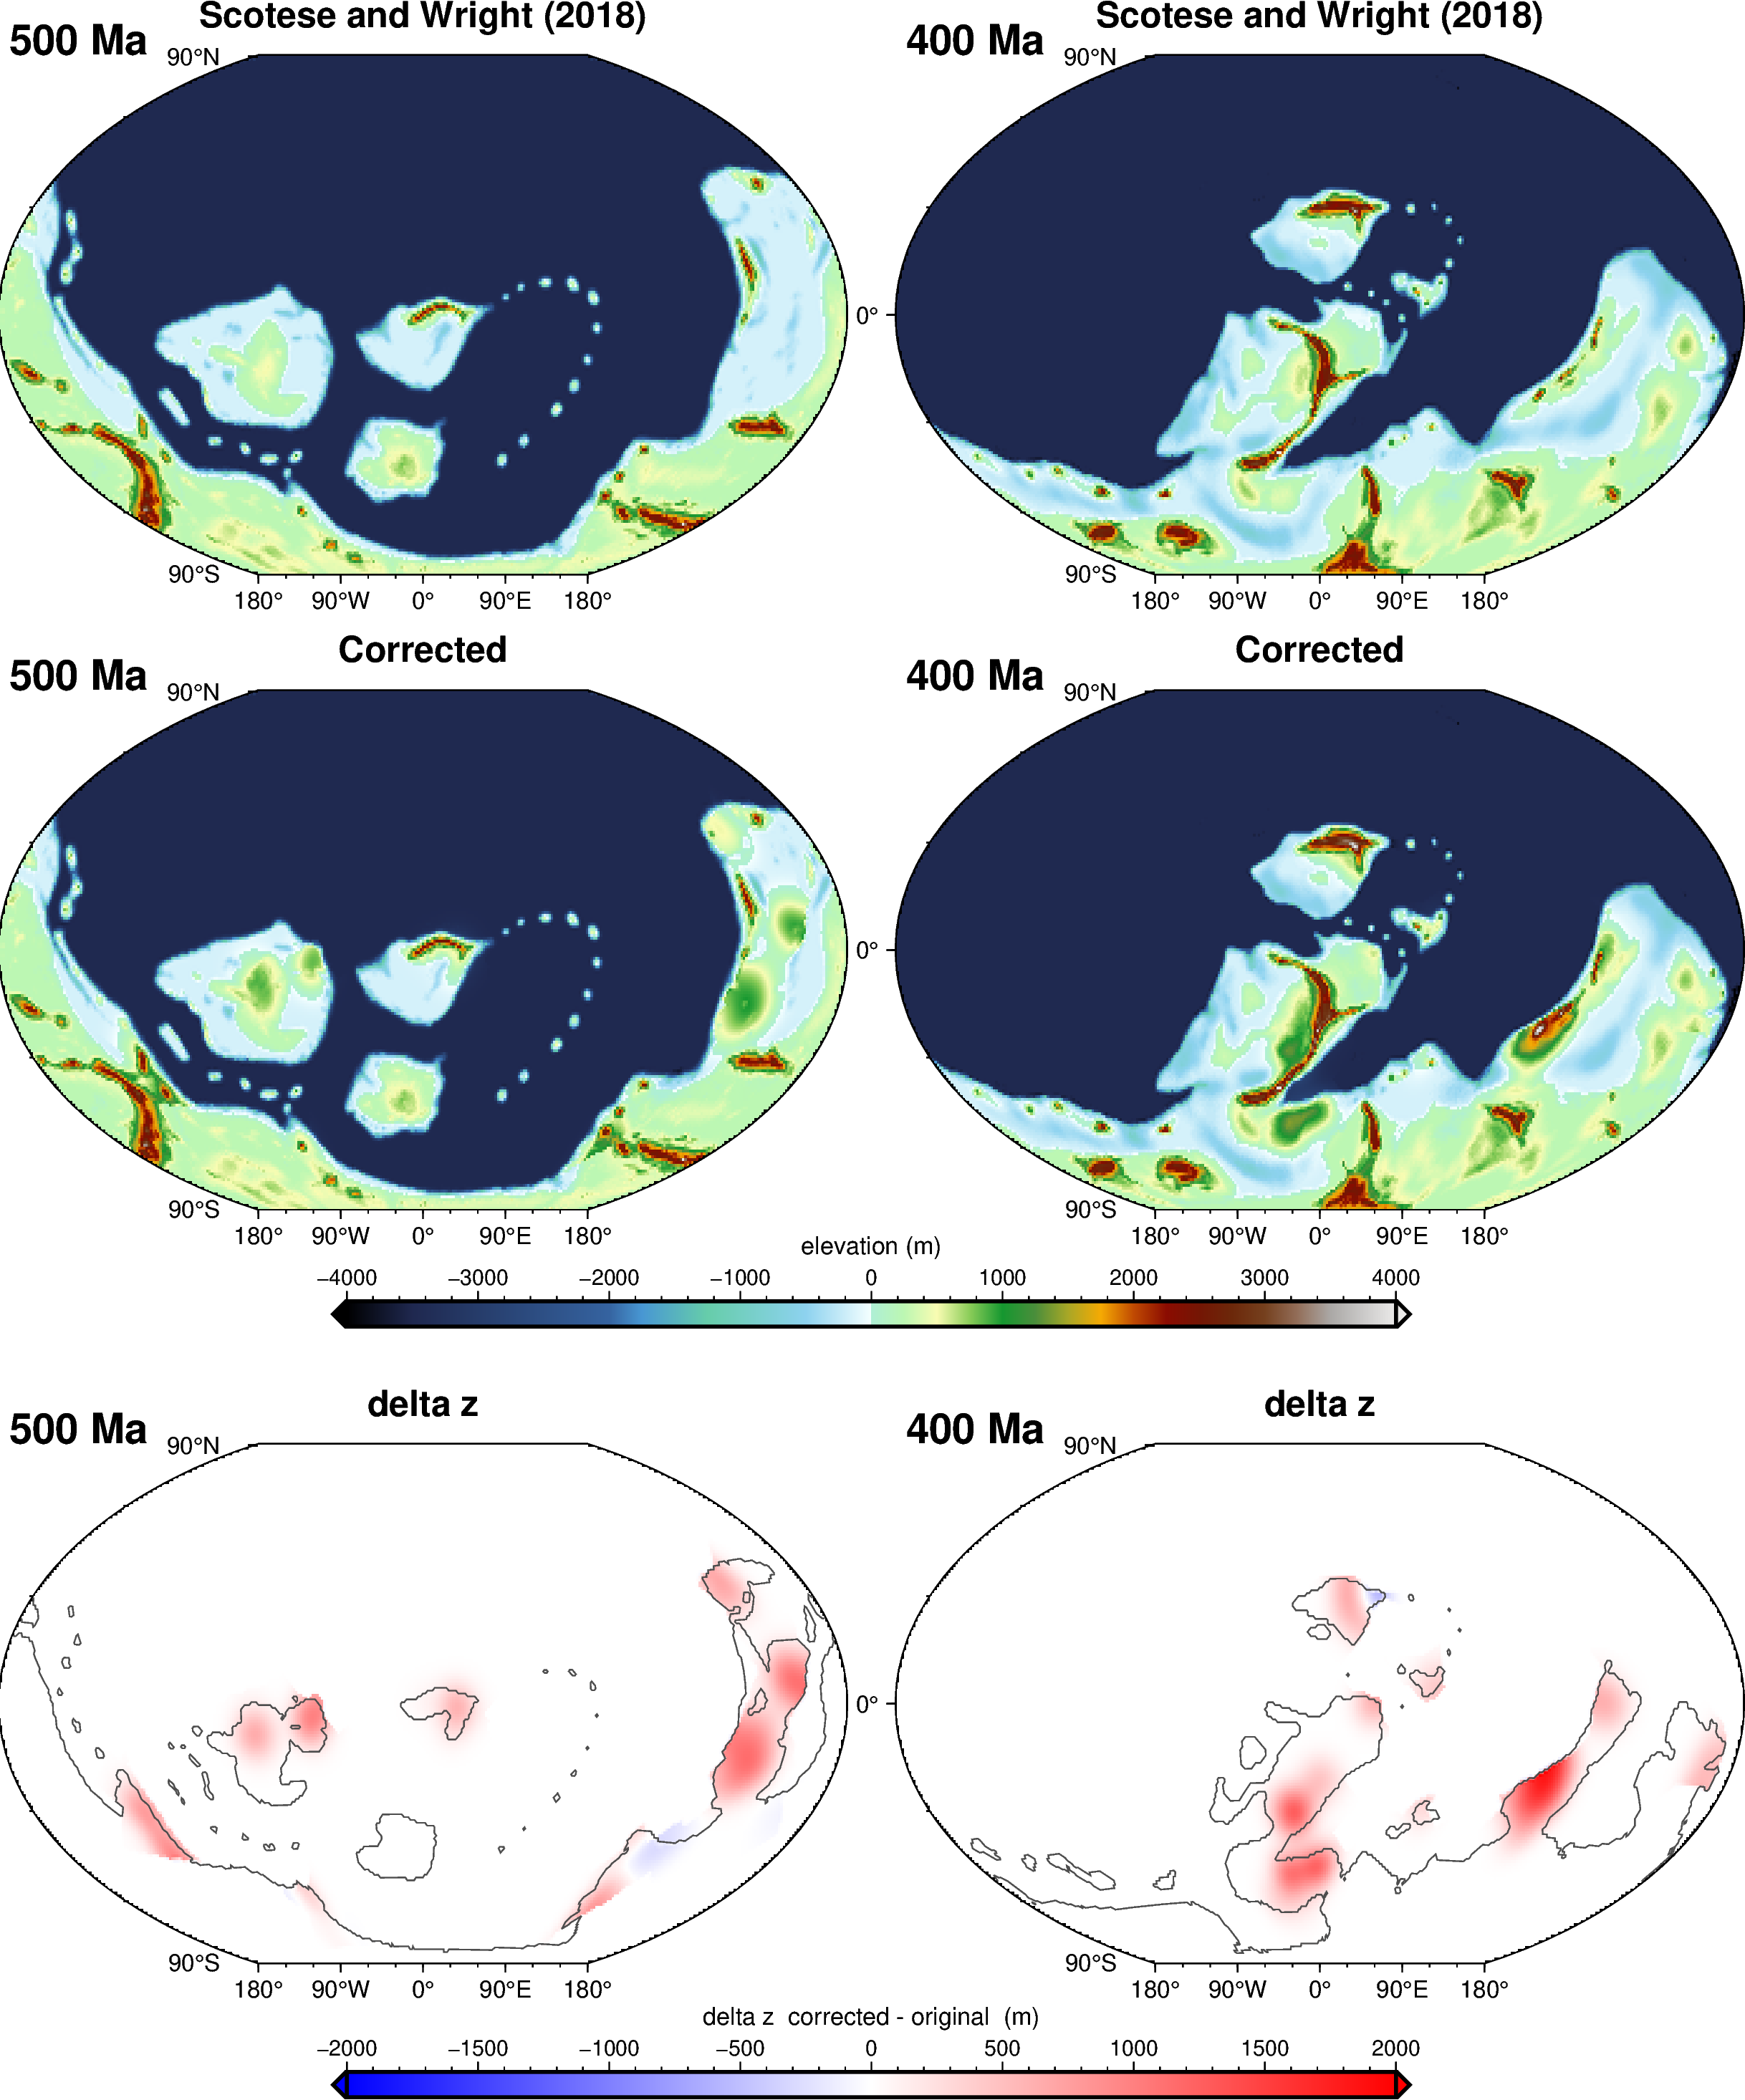


=== 300-200Ma: 300 Ma | 200 Ma ===
  saved: paleotopo_scotese_figs/T42_SW_comparison_300-200Ma.png


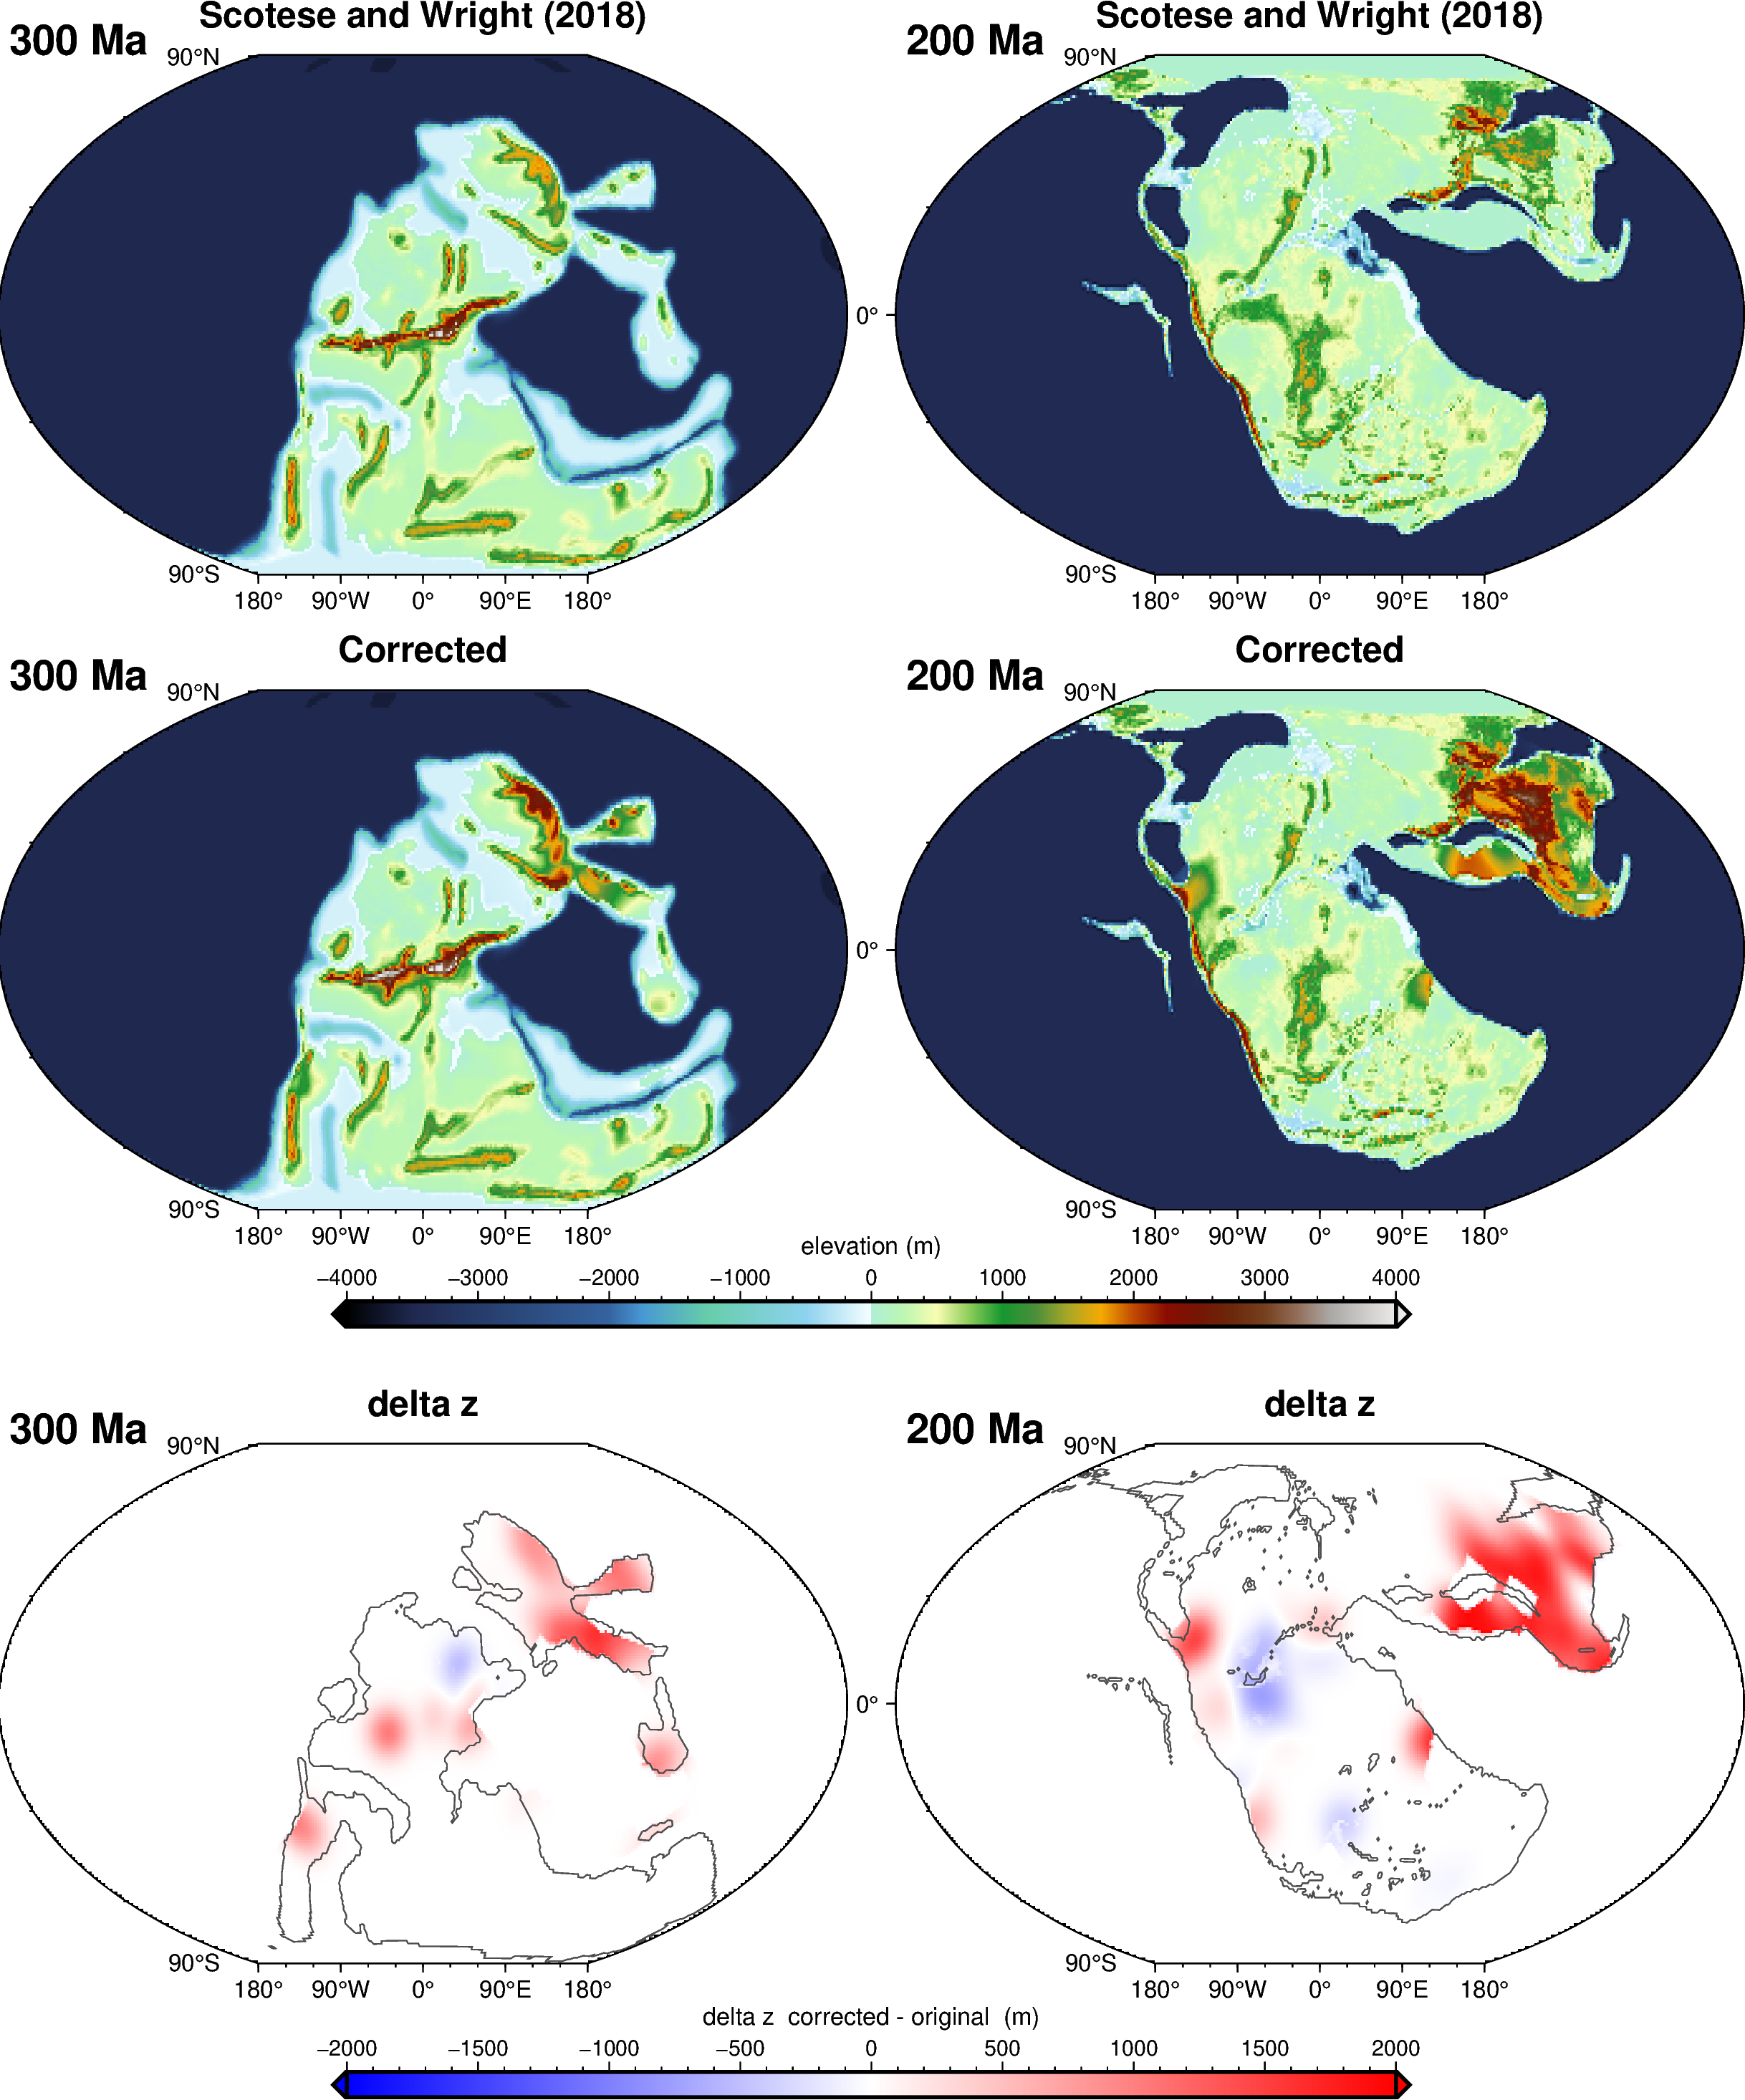


=== 100-50Ma: 100 Ma | 50 Ma ===
  saved: paleotopo_scotese_figs/T42_SW_comparison_100-50Ma.png


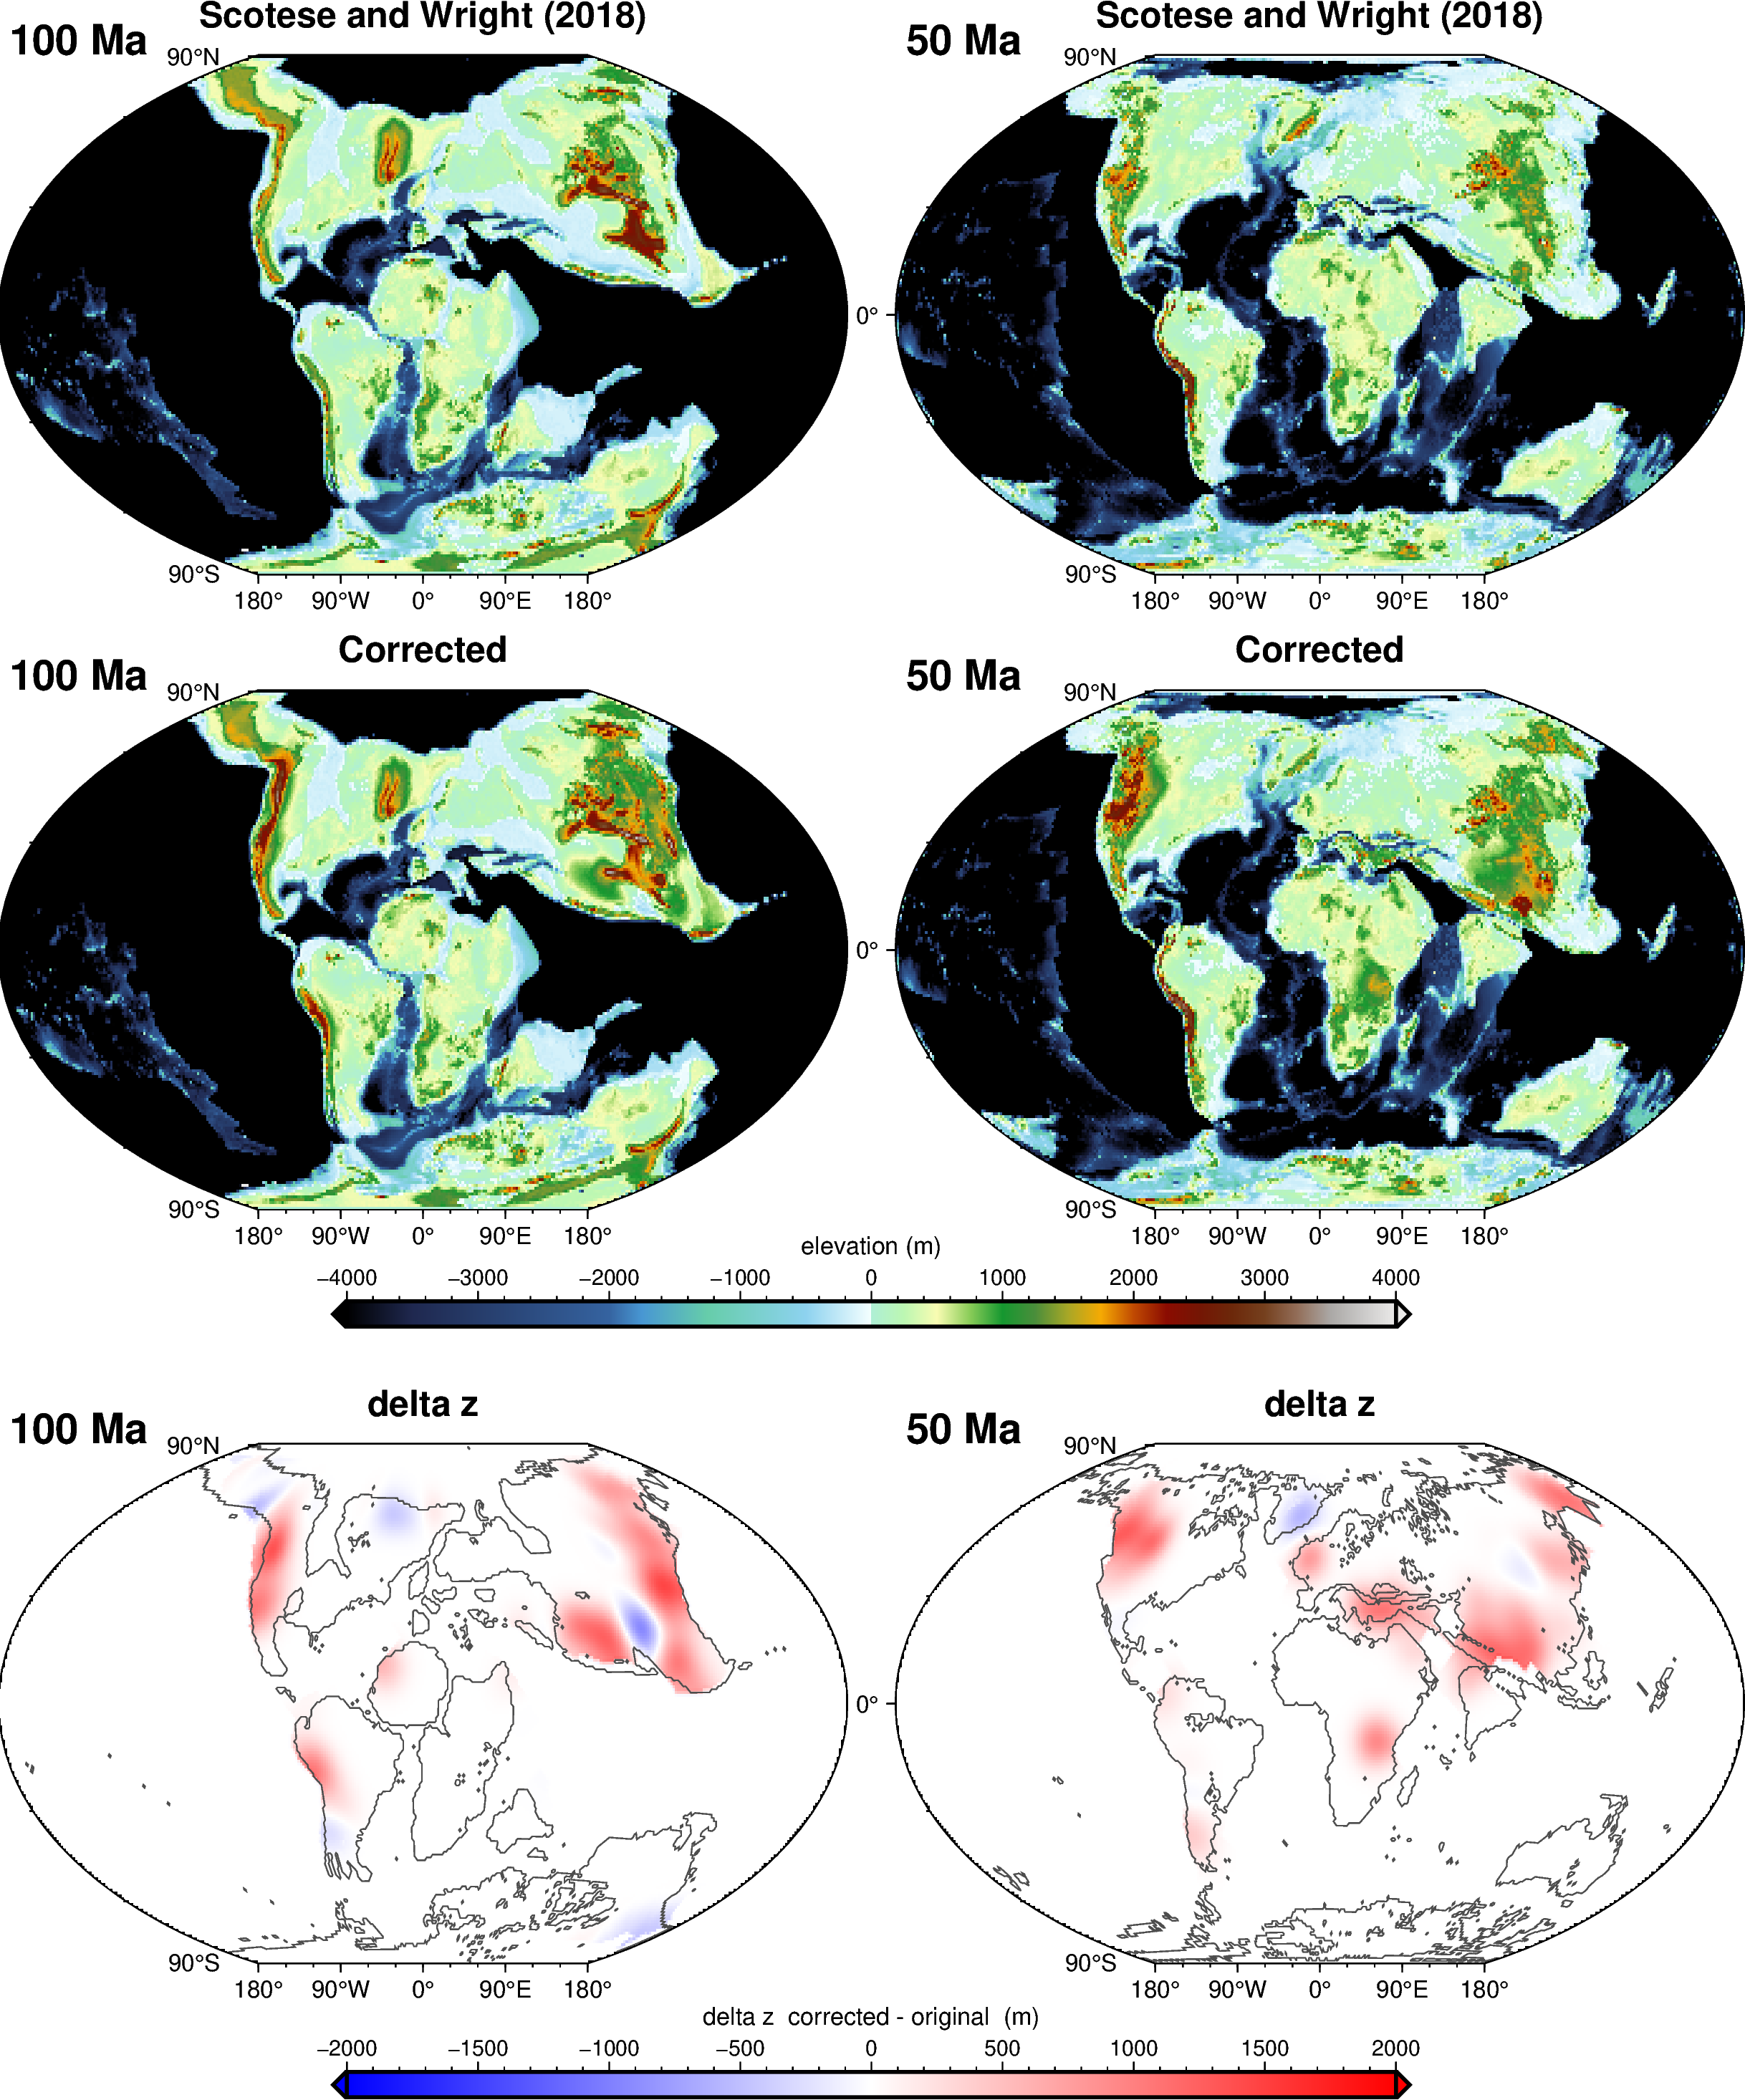

In [4]:
# Build the three comparison figures (500-400, 300-200, 100-50 Ma).
for age_l, age_r, label in AGE_PAIRS:
    make_comparison_figure(age_l, age_r, label)


## 2. Scotese-Wright vs corrected, with delta z

Three pyGMT figures (one per age pair) each laid out as a 2×3 grid:

- Row 1 (top): original Scotese & Wright (2018) (https://www.earthbyte.org/paleodem-resource-scotese-and-wright-2018/) PaleoDEM
- Row 2 (middle): geochemistry-corrected paleo-DEM
- Row 3 (bottom): Δz = corrected - original

Columns are the two ages in the pair (left = older, right = younger).
A shared elevation colourbar runs under row 2; a separate diverging
Δz colourbar runs under row 3. Continental outlines are derived from
the rendered field (M ≥ 0) so they match the elevation actually
plotted, avoiding the polygon-vs-paleoDEM mismatch that surfaces in
deep time.

> The original `make_comparison_figures.py` also overlays declustered
> assimilation samples as small black circles on the Δz panels. That
> overlay needs the full `assimilate_scotese.py` reconstructor pipeline
> (Scotese-Wright rotation model + topologies + 1100-line module) and
> is deliberately omitted here to keep the bundled dependency footprint
> small. See the *Extend this* section below for how to wire it back in.
